<a href="https://colab.research.google.com/github/Nicolas-1802/ColabProjects/blob/main/PDI/Pratica_Filtragem_Espacial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Universidade do Vale do Itajaí<br>
Escola Politécnica<br>
Processamento Digital de Sinais: Imagens

# Exercício Avalitivo de Filtragem Espacial

### Tutoriais da OpenCV

- https://docs.opencv.org/master/d9/df8/tutorial_root.html
- https://www.geeksforgeeks.org/opencv-python-tutorial/

## Conversão de imagem RGB em imagem Grayscale

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow


In [54]:
#abria a imagem
img = cv2.imread('/content/img_after_save.png',0)
#cv2_imshow(img)

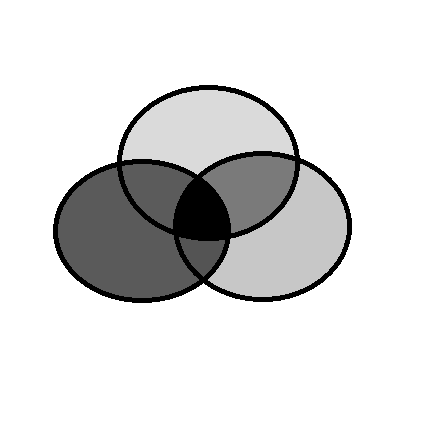

In [55]:
#mostrando a imagem colorida
cv2_imshow(img)
cv2.waitKey(0)
cv2.destroyAllWindows()

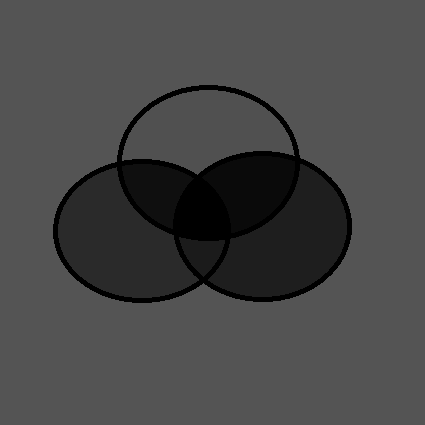

In [51]:
#aplicando conversão básica
#numpy
img_grayscale_basic = (img[ : , : ,0]+img[ : , : ,1]+img[ : , : ,2])/3

#cv2
B, G, R = cv2.split(img)
img_grayscale_basic = (B+G+R)/3

img_grayscale_basic = np.array(img_grayscale_basic, dtype=np.uint8)

cv2_imshow(img_grayscale_basic)
cv2.waitKey(0)
cv2.destroyAllWindows()

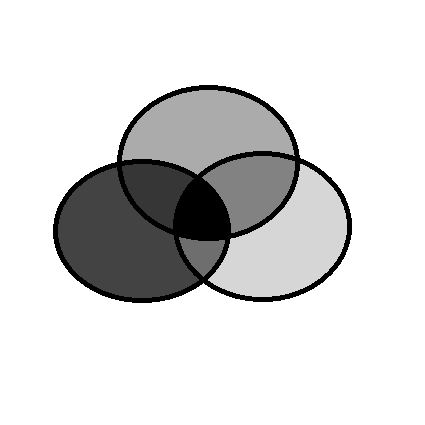

In [52]:
#aplicando conversão ponderada
img_grayscale_basic = 0.299*img[ : , : ,0] + 0.587*img[ : , : ,1] + 0.114*img[ : , : ,2]

#cv2
B, G, R = cv2.split(img)
img_grayscale_pondered = 0.299*B+0.587*G+0.114*R

img_grayscale_pondered = np.array(img_grayscale_pondered, dtype=np.uint8)

cv2_imshow(img_grayscale_pondered)
cv2.waitKey(0)
cv2.destroyAllWindows()

## Filtro Espacial


In [53]:
def gauss_create(sigma=1, size_x=3, size_y=3):
    '''
    Create normal (gaussian) distribuiton
    '''
    x, y = np.meshgrid(np.linspace(-1,1,size_x), np.linspace(-1,1,size_y))
    calc = 1/((2*np.pi*(sigma**2)))
    exp = np.exp(-(((x**2) + (y**2))/(2*(sigma**2))))

    return exp*calc



### Suavização

1. Implemente a sua própria convolução manualmente, em formato de função, utilizando os conceitos vistos em aula
2. Aplique a filtragem de suavização, com as máscaras 3x3, 5x5 e 7x7, com os filtros:
 - média
 - gaussino (escolha uma distribuição adequada, podendo utilizar a função acima ou recuperando a distribuição usada na OpenCV)
 - mediana
3. Relate as observações visíveis nas imagens de saída com os filtros usados, descrevendo o comportamento visual em relação as bordas, ruídos e esmaecimento da imagem com os diferentes kernels

#### Dicas
 - Você pode adicionar ruído nas imagens usando a função random_noise: `from skimage.util import random_noise`. Cuidado com o retorno da função, talvez seja necessário regularizar a mesma novamente para o intervalo de 0 à 255.

In [56]:
def add_padding(img, padding_height, padding_width):
    n, m = img.shape

    padded_img = np.zeros((n + padding_height * 2, m + padding_width * 2))
    padded_img[padding_height : n + padding_height, padding_width : m + padding_width] = img

    return padded_img

In [64]:
def conv2d(img, kernel, padding=True):
    # Get dimensions of the kernel
    k_height, k_width = kernel.shape  # Atribui valor à variável k_height, k_width

    # Get dimensions of the image
    img_height, img_width = img.shape  # Atribui valor à variável img_height, img_width

    # Calculate padding required
    pad_height = k_height // 2  # Atribui valor à variável pad_height
    pad_width = k_width // 2  # Atribui valor à variável pad_width

    # Create a padded version of the image to handle edges
    if padding == True:
        padded_img = add_padding(img, pad_height, pad_width)  # Atribui valor à variável padded_img


    # Initialize an output image with zeros
    output = np.zeros((img_height, img_width), dtype=float)  # Atribui valor à variável output

    # Perform convolution
    for i in range(img_height):
        for j in range(img_width):
            soma = 0.0

            for ki in range(k_height):
                for kj in range(k_width):
                    soma += padded_img[i + ki, j + kj] * kernel[ki, kj]

            output[i, j] = soma

    output = np.clip(output, 0, 255)


    return np.array(output, dtype=np.uint8)

In [104]:
def normalize_image(img):
    img = np.abs(img)
    img = np.clip(img, 0, 255)
    return img.astype(np.uint8)

Kernel Gaussiano

In [59]:
def gauss_create(sigma=1, size_x=3, size_y=3):
    x_axis = np.linspace(-(size_x // 2), size_x // 2, size_x)
    y_axis = np.linspace(-(size_y // 2), size_y // 2, size_y)

    x, y = np.meshgrid(x_axis, y_axis)

    calc = 1 / (2 * np.pi * (sigma ** 2))
    exp = np.exp(-((x ** 2 + y ** 2) / (2 * (sigma ** 2))))

    kernel = exp * calc
    kernel = kernel / kernel.sum()

    return kernel.astype(np.float32)

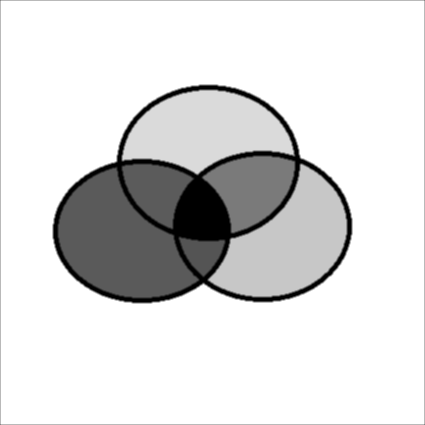

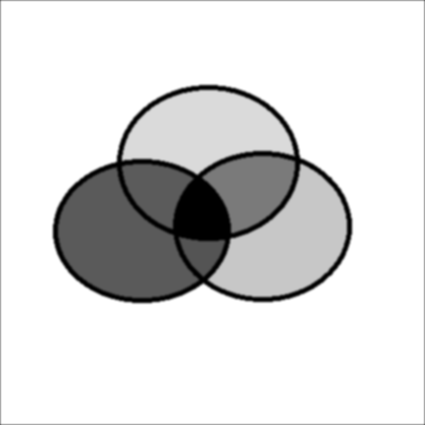

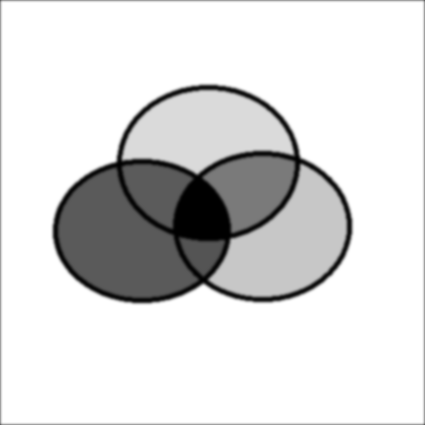

In [113]:
img_gauss_3 = conv2d(img, gauss_create(sigma=1.0, size_x=3, size_y=3))
img_gauss_5 = conv2d(img, gauss_create(sigma=1.2, size_x=5, size_y=5))
img_gauss_7 = conv2d(img, gauss_create(sigma=1.5, size_x=7, size_y=7))

cv2_imshow(img_gauss_3)
cv2_imshow(img_gauss_5)
cv2_imshow(img_gauss_7)

Kernel Média



In [58]:
def mean_kernel(size):
    kernel = np.ones((size, size), dtype=np.float32)
    kernel = kernel / (size * size)
    return kernel

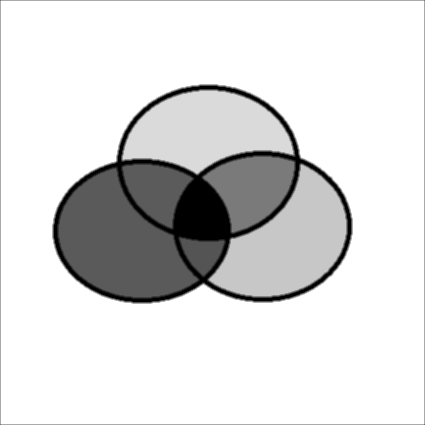

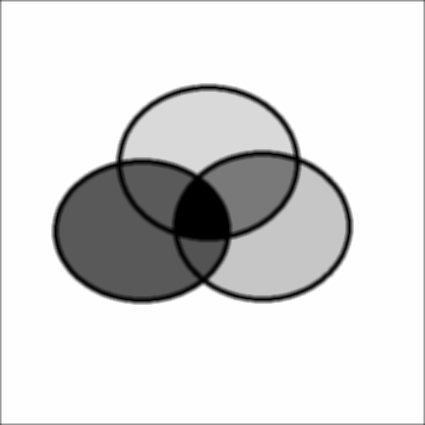

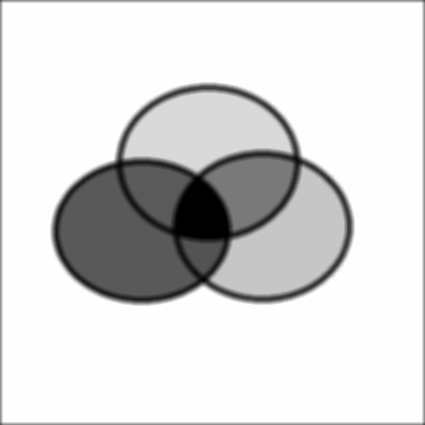

In [65]:
img_mean_3 = conv2d(img, mean_kernel(3))
img_mean_5 = conv2d(img, mean_kernel(5))
img_mean_7 = conv2d(img, mean_kernel(7))

cv2_imshow(img_mean_3)
cv2_imshow(img_mean_5)
cv2_imshow(img_mean_7)

Filtro Mediana

In [60]:
def median_filter(img, size, padding=True):
    img_height, img_width = img.shape
    pad = size // 2

    if padding == True:
        padded_img = add_padding(img, pad, pad)
    else:
        padded_img = img.copy()

    output = np.zeros((img_height, img_width), dtype=float)

    for i in range(img_height):
        for j in range(img_width):
            region = padded_img[i:i+size, j:j+size]

            values = []
            for ki in range(size):
                for kj in range(size):
                    values.append(region[ki, kj])

            values.sort()
            middle = len(values) // 2
            output[i, j] = values[middle]

    return np.array(output, dtype=np.uint8)

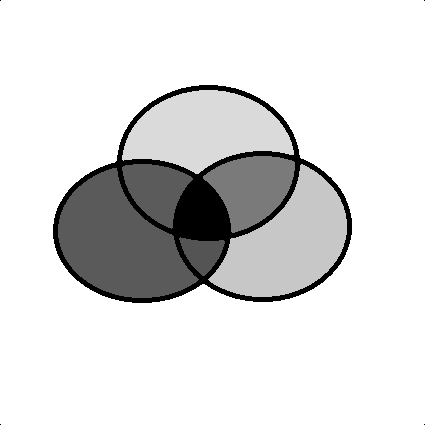

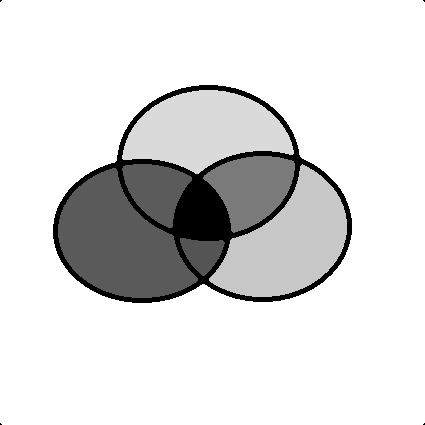

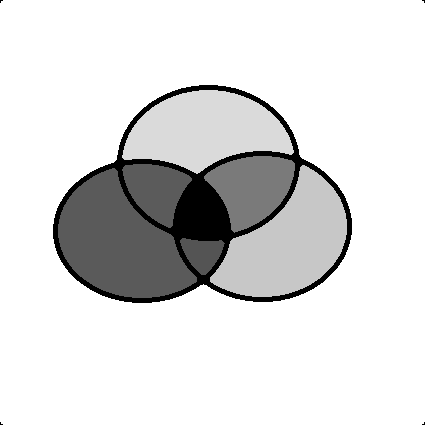

In [63]:
img_median_3 = median_filter(img, 3)
img_median_5 = median_filter(img, 5)
img_median_7 = median_filter(img, 7)

cv2_imshow(img_median_3)
cv2_imshow(img_median_5)
cv2_imshow(img_median_7)

### Sharpening

4. Implemente os filtros de sharpening, utilizando as diferentes mascarás apresentadas no livro de referência da disciplina:
 - Laplaciano (figura 3.37)
 - Sharpening implementado na figura 3.38
 - Unsharp Masking e Highboost Filtering
 - Implemente os detectores de borda Laplaciano, Roberts e Sobel
 - Utilize a função Canny da OpenCV na mesma imagem usando nos outros detectores

5. Relate as observações visíveis nas imagens de saída com os filtros usados, descrevendo o comportamento visual em relação as bordas, ruídos e esmaecimento da imagem com os diferentes kernels e para os diferentes algoritmos
6. Você observa uma discrepante melhoria na detecção de bordas pelo Canny em comparação aos outros 3 que justifique a complexidade adicional?
7. Aplique o filtro Sobel pós operação com um filtro de suavização (a sua escolha) e compare com a saída do Canny. Descreva suas observações técnicas sobre o comportamento.

**Máscaras Laplacianas**

In [87]:
laplacian_4 = np.array([
    [ 0, -1,  0],
    [-1,  4, -1],
    [ 0, -1,  0]
], dtype=np.float32)

In [88]:
laplacian_8 = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=np.float32)

Detector de borda Laplaciano

In [89]:
def edge_laplacian(img, lap_kernel):
    edge = conv2d(img, lap_kernel)
    return normalize_image(edge)

Sharpening com Laplaciano

In [90]:
def sharpen_laplacian(img, lap_kernel):
    lap = conv2d(img, lap_kernel)
    sharp = img.astype(np.float32) - lap
    sharp = np.clip(sharp, 0, 255)
    return sharp.astype(np.uint8)

Unsharp Masking

In [114]:
def unsharp_masking(img, blur_kernel):
    blurred = conv2d(img, blur_kernel)
    mask = img.astype(np.float32) - blurred
    result = img.astype(np.float32) + mask

    return normalize_image(result), normalize_image(blurred), mask

Highboost Filtering

In [92]:
def highboost_filter(img, blur_kernel, k=1.5):
    blurred = conv2d(img, blur_kernel)
    mask = img.astype(np.float32) - blurred
    result = img.astype(np.float32) + k * mask

    return normalize_image(result), normalize_image(blurred), mask

**DETECTORES DE BORDA**

Roberts

In [93]:
roberts_x = np.array([
    [1, 0],
    [0, -1]
], dtype=np.float32)

In [94]:
roberts_y = np.array([
    [0, 1],
    [-1, 0]
], dtype=np.float32)

In [95]:
def edge_roberts(img):
    gx = conv2d(img, roberts_x, padding=True)
    gy = conv2d(img, roberts_y, padding=True)

    magnitude = np.sqrt(gx**2 + gy**2)
    return normalize_image(magnitude)

Sobel

In [97]:
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

In [98]:
sobel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=np.float32)

In [75]:
def edge_sobel(img):
    gx = conv2d(img, sobel_x)
    gy = conv2d(img, sobel_y)

    magnitude = np.sqrt(gx**2 + gy**2)
    return normalize_image(magnitude), gx, gy

Canny

In [76]:
def edge_canny(img, th1=100, th2=200):
    return cv2.Canny(img, th1, th2)

**APLICAÇÕES**

Laplaciano e sharpening

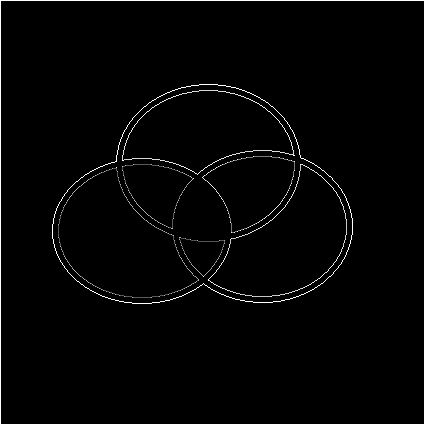

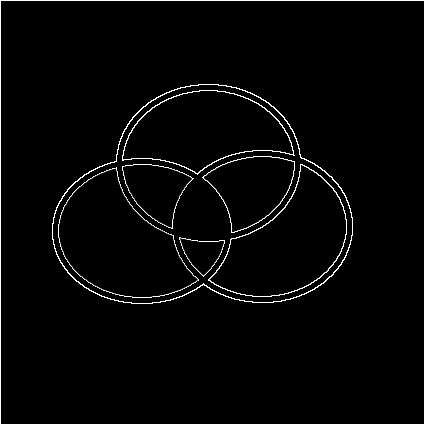

In [105]:
lap_edge_4 = edge_laplacian(img, laplacian_4)
lap_edge_8 = edge_laplacian(img, laplacian_8)

cv2_imshow(lap_edge_4)
cv2_imshow(lap_edge_8)

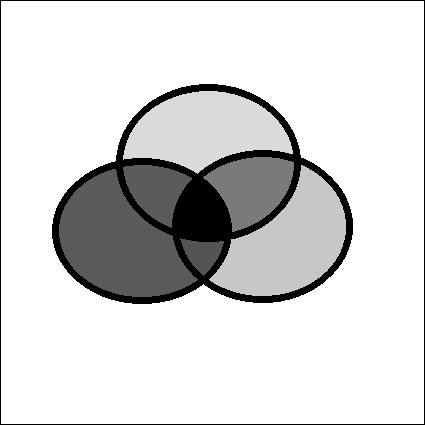

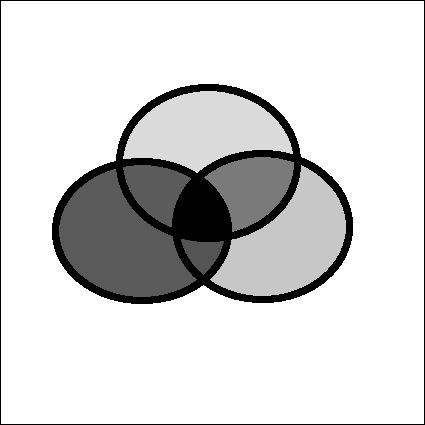

In [106]:
sharp_lap_4 = sharpen_laplacian(img, laplacian_4)
sharp_lap_8 = sharpen_laplacian(img, laplacian_8)

cv2_imshow(sharp_lap_4)
cv2_imshow(sharp_lap_8)

Unsharp Masking e Highboost

In [107]:
gauss_5 = gauss_create(sigma=1.2, size_x=5, size_y=5)

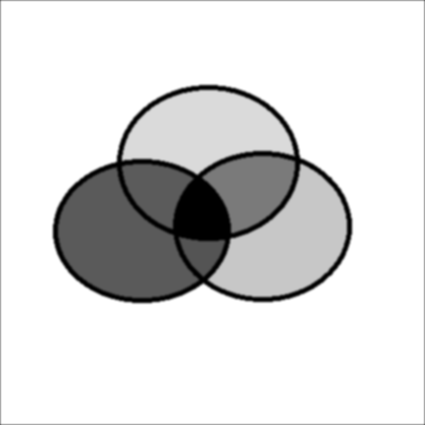

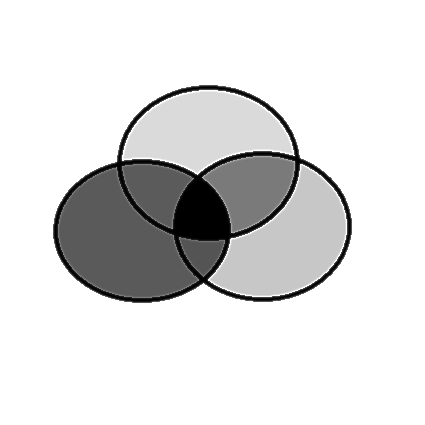

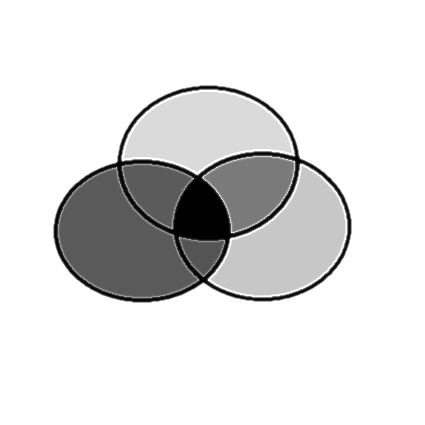

In [108]:
unsharp_img, blurred_unsharp, unsharp_mask = unsharp_masking(img, gauss_5)
highboost_img, blurred_high, highboost_mask = highboost_filter(img, gauss_5, k=2.0)

cv2_imshow(blurred_unsharp)
cv2_imshow(unsharp_img)
cv2_imshow(highboost_img)

Detectores de borda

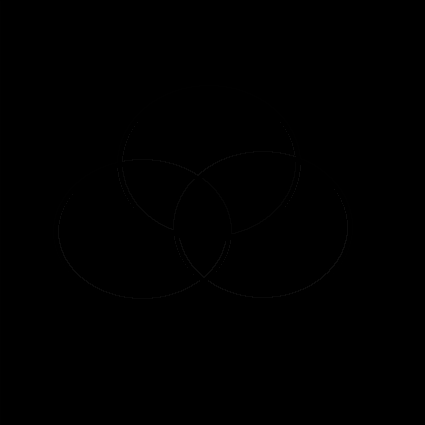

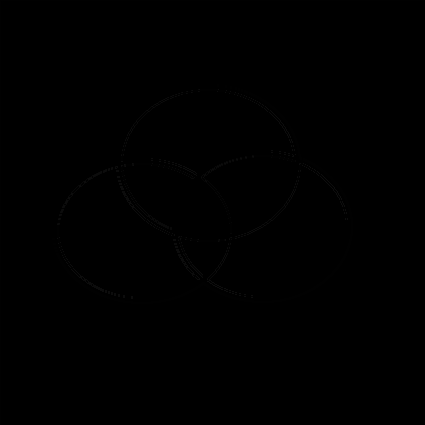

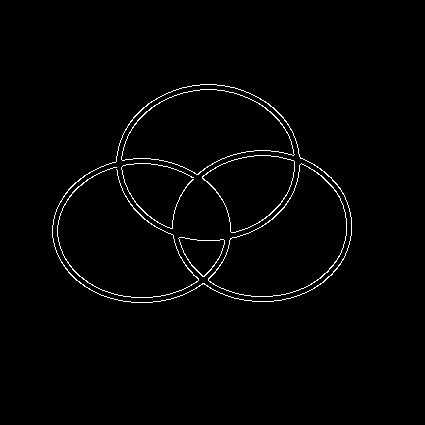

In [109]:
roberts_img = edge_roberts(img)
sobel_img, sobel_gx, sobel_gy = edge_sobel(img)
canny_img = edge_canny(img, 100, 200)

cv2_imshow(roberts_img)
cv2_imshow(sobel_img)
cv2_imshow(canny_img)

**Sobel após suavização**

Com média

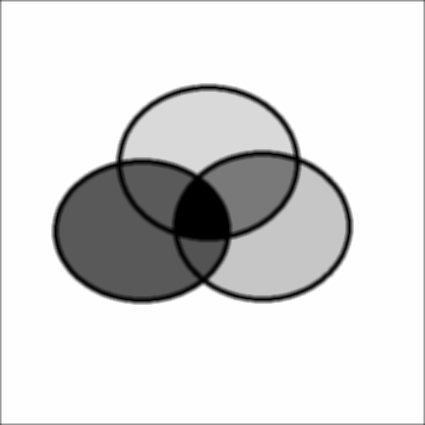

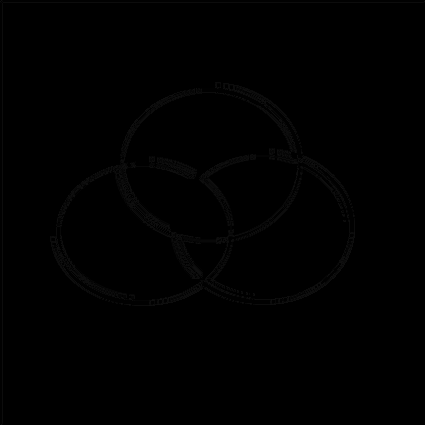

In [110]:
img_mean_5 = conv2d(img, mean_kernel(5))
img_mean_5 = normalize_image(img_mean_5)

sobel_after_mean, _, _ = edge_sobel(img_mean_5)

cv2_imshow(img_mean_5)
cv2_imshow(sobel_after_mean)

Com gaussiano

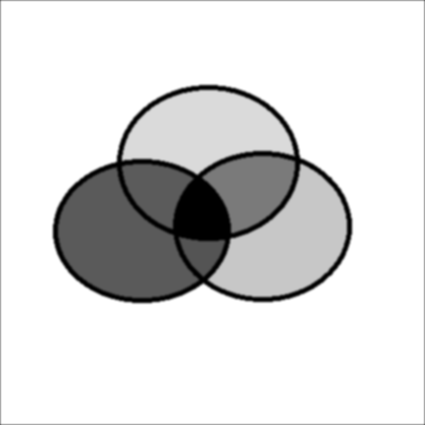

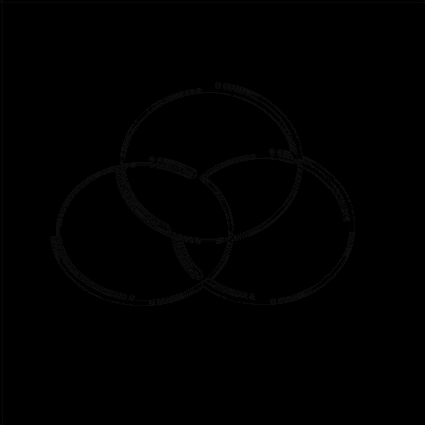

In [111]:
img_gauss_5 = conv2d(img, gauss_5)
img_gauss_5 = normalize_image(img_gauss_5)

sobel_after_gauss, _, _ = edge_sobel(img_gauss_5)

cv2_imshow(img_gauss_5)
cv2_imshow(sobel_after_gauss)

Comparação com Canny

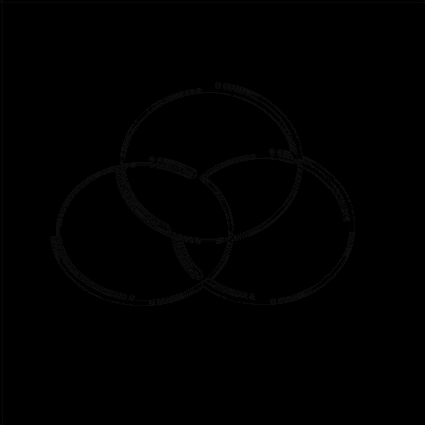

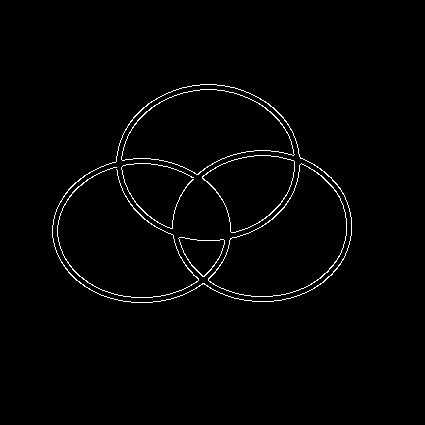

In [112]:
cv2_imshow(sobel_after_gauss)
cv2_imshow(canny_img)